# Examples for Geodesics on Toy Datasets

In [1]:
# libraries 
import torch 
import numpy as np 
from matplotlib import pyplot as plt 
import os
from functools import partial

In [ ]:
%cd score-based-riemannian-metrics/

/home/moritz.burmester/riem-score-metrics


In [4]:
# local imports
from experiments_toy_datasets.manifolds.score_metrics import *
from experiments_toy_datasets.discrete_geodesics import *
from experiments_toy_datasets.graph_based_initialization import *
from experiments_toy_datasets.toy_datasets_utils import *
from experiments_toy_datasets.plotting import *
from experiments_toy_datasets.sample_pairs import *

(<Figure size 1300x650 with 2 Axes>,
 array([<AxesSubplot:title={'center':'1-sphere'}>,
        <AxesSubplot:title={'center':'s-curve'}>], dtype=object))

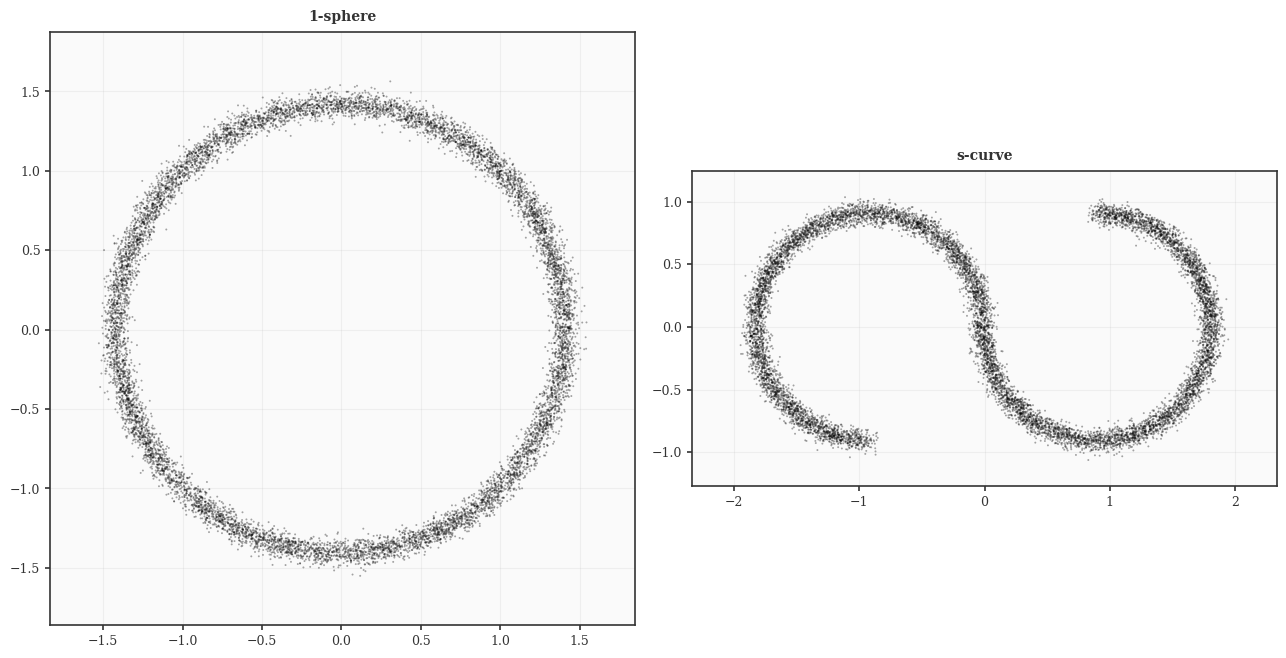

In [5]:
# plot the datasets 
datasets = ['1-sphere', 's-curve']
plot_grid(datasets, kind='data')

## Geodesics on S-Curve and Circle

In [9]:
data_dir = 'score-based-riemannian-metrics/experiments_toy_data/toy_datasets' 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Geodesics with INVP metric, with linear-init

In [16]:
n_points = 50
n_iter = 5000
lr = 5e-3
save_dir = '/home/moritz.burmester/score-based-riemannian-metrics/experiments_toy_datasets/curves'
os.makedirs(save_dir, exist_ok=True)

for ds_name in datasets:
    print(f'Dataset: {ds_name}')
    ## load the datasets 
    ds = load_dataset(ds_name, data_dir)
    X, meta = ds['X'], ds['meta']
    X = torch.tensor(X, dtype=torch.float32, device=device)
    idx = torch.randperm(X.shape[0])
    reference_points = X[idx[:2000]]


    # get the gmm parameters 
    means, sigma, weights = get_gmm_components(ds_name, meta, n_components=1500)
    deriv = AnalyticDeriv(means, sigma, weights).to(device=device) # provides score function, Hessian, logp, etc. 

    # define the metric, e.g. PER, SAI, AZE, INVP or ours (G_lam)
    # INVP, unnormalized
    manifold, _ = build_INVP(deriv=deriv, reference_points=reference_points, normalize=False)

    # optional: normalize the metric and cast it to be 1 on manifold, 1000 of manifold 
    #noisy_reference_points = torch.cat([reference_points] + [reference_points + 0.3*torch.randn_like(reference_points) for _ in range(2)], 0)
    #manifold, _ = build_INVP(deriv=deriv, reference_points=noisy_reference_points, target_min=1.0, target_max=1000, normalize=True)
    
    # sample pairs from the datasets (n = 1 here for example purposes)
    pairs = get_pairs(ds_name, meta, n_pairs = 1)

    # optimize geodesics (linear initialization for now)

    for pair_idx, (z0_np, z1_np) in enumerate(pairs):
            z0 = torch.tensor(z0_np, dtype=torch.float32, device=device)
            z1 = torch.tensor(z1_np, dtype=torch.float32, device=device)

            # lerp init
            t = torch.linspace(0, 1, n_points)[:, None].to(device)
            z_init = (1 - t) * z0[None, :] + t * z1[None, :]
            # run optimization loop 
            tag = f'{ds_name}/INVP/p{pair_idx}_linear'
            # symmetric energy works slightly better, but more expensive
            curve, history = discrete_geodesic_with_init(manifold, z0, z1, z_init, verbose_tag=tag)

            # save geodesics to disk for plotting purposes 
            fname = f'{ds_name}_INVP_p{pair_idx}_linear.pt'
            torch.save({
                'curve':         curve,
                'z0':            torch.tensor(z0_np),
                'z1':            torch.tensor(z1_np),
                'metric':        'INVP',
                'dataset':       ds_name,
                'pair_idx':      pair_idx,
            }, os.path.join(save_dir, fname))

Dataset: 1-sphere
1-sphere/INVP/p0_linear, ep=0, loss=12141942.0
1-sphere/INVP/p0_linear, ep=499, loss=667587.75
1-sphere/INVP/p0_linear, ep=999, loss=1389.810302734375
1-sphere/INVP/p0_linear, ep=1499, loss=322.95916748046875
1-sphere/INVP/p0_linear, ep=1999, loss=246.94284057617188
1-sphere/INVP/p0_linear, ep=2499, loss=218.9069061279297
1-sphere/INVP/p0_linear, ep=2999, loss=204.56163024902344
1-sphere/INVP/p0_linear, ep=3499, loss=196.04945373535156
1-sphere/INVP/p0_linear, ep=3999, loss=190.52748107910156
1-sphere/INVP/p0_linear, ep=4499, loss=186.69436645507812
1-sphere/INVP/p0_linear, ep=4999, loss=183.86734008789062
Dataset: s-curve
s-curve/INVP/p0_linear, ep=0, loss=7314166.0
s-curve/INVP/p0_linear, ep=499, loss=1163.890869140625
s-curve/INVP/p0_linear, ep=999, loss=349.83953857421875
s-curve/INVP/p0_linear, ep=1499, loss=208.69485473632812
s-curve/INVP/p0_linear, ep=1999, loss=152.98086547851562
s-curve/INVP/p0_linear, ep=2499, loss=123.97492218017578
s-curve/INVP/p0_linear, 

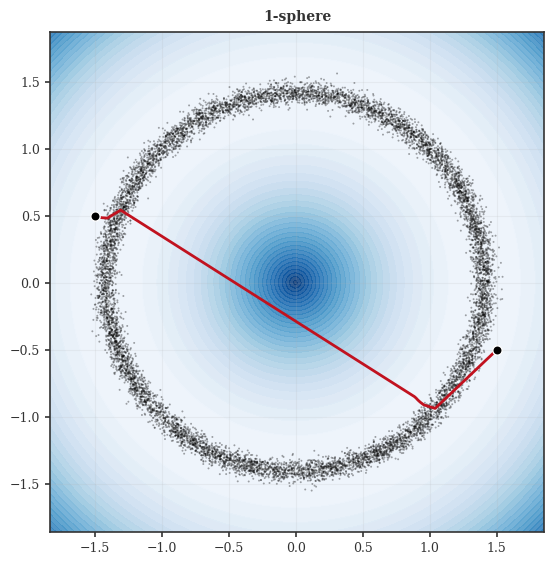

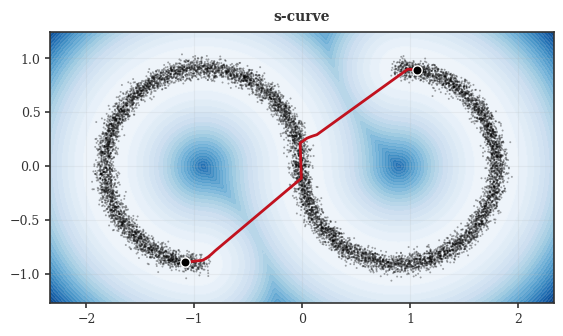

In [17]:
# plot geodesics
for ds_name in datasets: 
    for pair_idx, _ in enumerate(pairs):
        plot_curve(ds_name,
                f"/home/moritz.burmester/score-based-riemmanian-metrics/experiments_toy_datasets/curves/{ds_name}_INVP_p{pair_idx}_linear.pt")



Geodesics with linear interpolation as initialized curve often fail to escape the local minima, at least for energy minimization.
--> Solution: Initialize with a better guess instead

### Geodesics with INVP metric, with graph-init

In [ ]:
# Geodesics with graph-init 

n_points = 50
n_iter = 5000
lr = 5e-3
save_dir = '/home/moritz.burmester/score-based-riemmanian-metrics/experiments_toy_datasets/curves'
os.makedirs(save_dir, exist_ok=True)

for ds_name in datasets:
    print(f'Dataset: {ds_name}')
    ## load the datasets 
    ds = load_dataset(ds_name, data_dir)
    X, meta = ds['X'], ds['meta']
    X = torch.tensor(X, dtype=torch.float32, device=device)
    idx = torch.randperm(X.shape[0])
    reference_points = X[idx[:2000]]

    # get the gmm parameters 
    means, sigma, weights = get_gmm_components(ds_name, meta, n_components=1500)
    deriv = AnalyticDeriv(means, sigma, weights).to(device=device) # provides score function, Hessian, logp, etc. 

    # define the metric, e.g. PER, SAI, AZE, INVP or ours (G_lam)
    # INVP, unnormalized
    manifold, _ = build_INVP(deriv=deriv, reference_points=reference_points, normalize=False)
    # optional: normalize metric between 1 and 1000
    #noisy_reference_points = torch.cat([reference_points] + [reference_points + 0.3*torch.randn_like(reference_points) for _ in range(2)], 0)
    #manifold, _ = build_INVP(deriv=deriv, reference_points=noisy_reference_points, target_min=1.0, target_max=1000, normalize=True)

    # sample pairs from the datasets
    pairs = get_pairs(ds_name, meta, n_pairs = 1)

    # optimize geodesics with graph init 
    for pair_idx, (z0_np, z1_np) in enumerate(pairs):
            z0 = torch.tensor(z0_np, dtype=torch.float32, device=device)
            z1 = torch.tensor(z1_np, dtype=torch.float32, device=device)

            # graph init
            data_np = X.detach().cpu().numpy()
            z_init = graph_init_curve(manifold, data_np, z0, z1, n_points,
                     k=15, N_edge=4, weight_floor=1e-8,
                     subsample=2000, seed=0, device='cpu')

            # run optimization loop 
            tag = f'{ds_name}/INVP/p{pair_idx}_graph'
            # symmetric energy works a bit better, but more expensive
            curve, history = discrete_geodesic_with_init(manifold, z0, z1, z_init, verbose_tag=tag)

            # save geodesics to disk for plotting purposes 
            fname = f'{ds_name}_INVP_p{pair_idx}_graph.pt'
            torch.save({
                'curve':         curve,
                'z0':            torch.tensor(z0_np),
                'z1':            torch.tensor(z1_np),
                'metric':        'INVP',
                'dataset':       ds_name,
                'pair_idx':      pair_idx,
            }, os.path.join(save_dir, fname))

Dataset: 1-sphere
1-sphere/INVP/p0_graph, ep=0, loss=385.9742431640625
1-sphere/INVP/p0_graph, ep=499, loss=15.937954902648926
1-sphere/INVP/p0_graph, ep=999, loss=15.941527366638184
1-sphere/INVP/p0_graph, ep=1499, loss=15.954648971557617
1-sphere/INVP/p0_graph, ep=1999, loss=15.964858055114746
1-sphere/INVP/p0_graph, ep=2499, loss=15.937296867370605
1-sphere/INVP/p0_graph, ep=2999, loss=15.937684059143066
1-sphere/INVP/p0_graph, ep=3499, loss=15.938529968261719
1-sphere/INVP/p0_graph, ep=3999, loss=15.93695068359375
1-sphere/INVP/p0_graph, ep=4499, loss=15.949071884155273
1-sphere/INVP/p0_graph, ep=4999, loss=15.947701454162598
Dataset: s-curve
s-curve/INVP/p0_graph, ep=0, loss=33.42350769042969
s-curve/INVP/p0_graph, ep=499, loss=32.512107849121094
s-curve/INVP/p0_graph, ep=999, loss=32.51210403442383
s-curve/INVP/p0_graph, ep=1499, loss=32.51214599609375
s-curve/INVP/p0_graph, ep=1999, loss=32.51220703125
s-curve/INVP/p0_graph, ep=2499, loss=32.512210845947266
s-curve/INVP/p0_graph

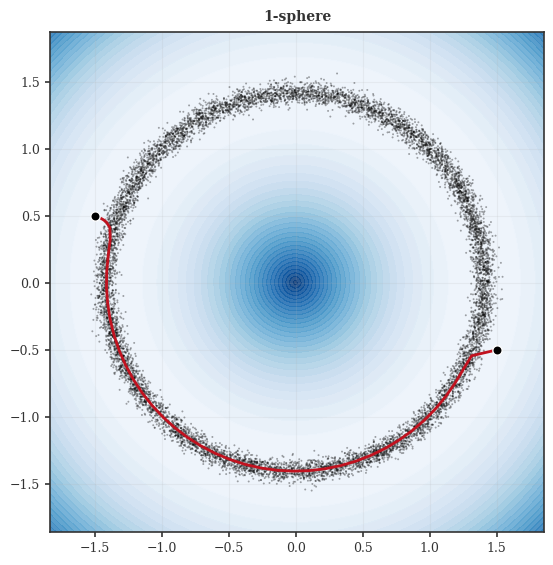

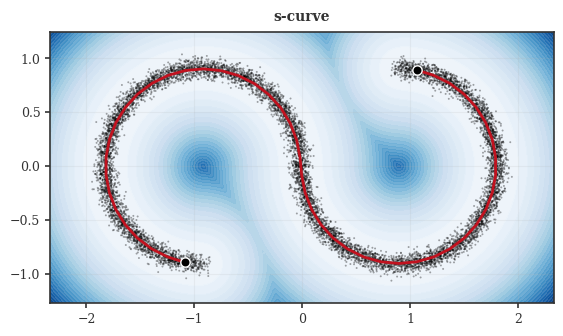

In [15]:
# plot geodesics
N_PAIRS = 1
for ds_name in datasets: 
    for pair_idx in range(N_PAIRS):
        plot_curve(ds_name,
                f"/home/moritz.burmester/score-based-riemannian-metrics/experiments_toy_datasets/curves/{ds_name}_INVP_p{pair_idx}_graph.pt")